# Global tropical cyclone best tracks

The International Best Track Archive for Climate Stewardship (IBTrACS)
merges the best tracks of every agency that tracks tropical cyclones, from
the U.S. National Hurricane Center and Joint Typhoon Warning Center to Tokyo,
New Delhi, Réunion, and the Southern Hemisphere centres, into one global
record since 1842. NOAA's National Centers for Environmental Information
(NCEI) publishes it as whole files, each one subset of the record as a CSV or
NetCDF file, and rebuilds them in place as agencies deliver tracks.

This walkthrough pulls the `last3years` CSV, every basin's storms for the
current season and the three before it, and maps the storms that reached
category 4 or 5. It needs `usdata[pandas]` and matplotlib (the NetCDF
format needs `usdata[netcdf]` instead), and downloads one 10 MB file in a
few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:11:30+00:00
usdata 0.26.0; pandas 3.0.6


## Select

IBTrACS has no query interface, so the manifest names one of the eleven files
NCEI builds and nothing else: `all`, `since1980`, `last3years`, `active`, or
one of seven basins. Dates, places, and variables are rejected rather than
ignored. `format` defaults to `csv`, and `version` could pin a product
version; without it the newest (`v04r01`) is used.

`last3years` moves with the calendar: it always holds the current season and
the three before it.

In [2]:
print(manifest.read_text())

name: recent-global-tracks
sources:
  - name: tracks
    dataset: noaa:ibtracs
    # One whole file: the last three seasons and the current one, every basin.
    # IBTrACS has no query interface, so dates and geographic filters are
    # rejected; filter the parsed table locally. The file is rebuilt in place
    # as agencies deliver best tracks, so the lockfile's checksum is the pin.
    params:
      subset: last3years



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning its checksum. The filename never changes, but NCEI rebuilds
the file most days, so the checksum, not the name, identifies these bytes.

In [3]:
result = pull(manifest)
item = result.one("tracks")
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: ibtracs.last3years.list.v04r01.csv
Bytes: 10521539
Source: https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.last3years.list.v04r01.csv
Retrieved (UTC): 2026-09-24T06:11:31+00:00
Checksum: sha256:60c5782aadb85a16848df1b26d8723091a03663c6357a18af88176eb42b23e2b


## Open

The CSV lays a units row under its header, so `item.open()` picks the
units-row reader and keeps the units in `attrs["units"]`. The table has one
row per three-hourly track point and 174 columns: identity (`SID`, `SEASON`,
`BASIN`, `NAME`), `ISO_TIME` in UTC without an offset, position (`LAT`,
`LON`), the responsible WMO agency's wind and pressure, then each agency's own
report in its own columns. The U.S. set (`USA_WIND`, `USA_PRES`, `USA_SSHS`)
is the most complete; `USA_SSHS` is the Saffir-Simpson category, with -5 to
-1 for depressions, subtropical, and post-tropical stages. `TRACK_TYPE` says
whether a storm's track is final (`main`) or still provisional.

In [4]:
tracks = item.open(parse_dates=["ISO_TIME"])
units = tracks.attrs["units"]
columns = ["SID", "SEASON", "BASIN", "NAME", "ISO_TIME", "LAT", "LON", "USA_WIND", "USA_SSHS"]
print(f"{len(tracks):,} track points, {tracks['SID'].nunique()} storms, {tracks.shape[1]} columns")
print("Units:", {name: units[name] for name in ["LAT", "LON", "USA_WIND", "USA_PRES", "DIST2LAND"]})
print(f"Longitude runs from {tracks['LON'].min()} to {tracks['LON'].max()}")
print(tracks.groupby(["SEASON", "TRACK_TYPE"])["SID"].nunique().unstack(fill_value=0))
tracks[columns].head()

22,252 track points, 383 storms, 174 columns
Units: {'LAT': 'degrees_north', 'LON': 'degrees_east', 'USA_WIND': 'kts', 'USA_PRES': 'mb', 'DIST2LAND': 'km'}
Longitude runs from -179.5 to 257.4
TRACK_TYPE  PROVISIONAL  US-PROVISIONAL  main
SEASON                                       
2023                  0               0    86
2024                  0               0   101
2025                  5              64    46
2026                 79               2     0


,SID,SEASON,BASIN,NAME,ISO_TIME,LAT,LON,USA_WIND,USA_SSHS
0,2023005S18142,2023,SP,HALE,2023-01-04 18:00:00,-18.2,142.0,20.0,-3
1,2023005S18142,2023,SP,HALE,2023-01-04 21:00:00,-18.1,142.5,20.0,-3
2,2023005S18142,2023,SP,HALE,2023-01-05 00:00:00,-18.1,143.0,20.0,-3
3,2023005S18142,2023,SP,HALE,2023-01-05 03:00:00,-18.1,143.5,20.0,-3
4,2023005S18142,2023,SP,HALE,2023-01-05 06:00:00,-18.1,144.1,20.0,-3


Longitudes past 180 are not errors: a track that crosses the date line keeps
its longitude continuous instead of jumping from 180 to -180, so its values
run on past 180. Taking longitude modulo 360 puts every point on one 0 to 360
axis, centred on the Pacific.

## A first look

Every track point of the four seasons in grey, and the whole tracks of the
storms that reached category 4 or 5 on the U.S. one-minute wind, coloured by
the basin each one started in.

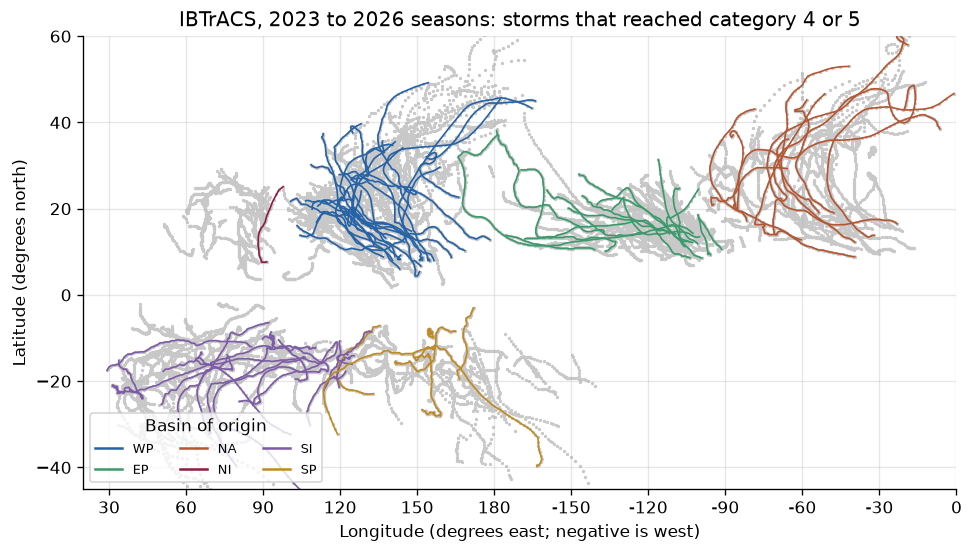

In [5]:
peak = tracks.groupby("SID")["USA_SSHS"].max()
majors = tracks[tracks["SID"].isin(peak[peak >= 4].index)]
colors = {"WP": "#2563a6", "EP": "#3a9a6b", "NA": "#b45631", "NI": "#8c1d40"}
colors |= {"SI": "#7d5ba6", "SP": "#c08a1e"}
fig, ax = plt.subplots(layout="constrained")
ax.scatter(tracks["LON"] % 360, tracks["LAT"], s=1, color="#c8c8c8")
for _, storm in majors.groupby("SID"):
    lon = (storm["LON"] % 360).to_numpy()
    # Break the line where a track wraps across 0/360 degrees.
    lon = np.where(np.abs(np.diff(lon, prepend=lon[0])) > 180, np.nan, lon)
    ax.plot(lon, storm["LAT"], color=colors[storm["BASIN"].iloc[0]], linewidth=1)
for basin, color in colors.items():
    ax.plot([], [], color=color, label=basin)
ax.set_xlim(20, 360)
ax.set_ylim(-45, 60)
ax.set_xticks(range(30, 361, 30), [f"{x if x <= 180 else x - 360}" for x in range(30, 361, 30)])
ax.set_xlabel("Longitude (degrees east; negative is west)")
ax.set_ylabel("Latitude (degrees north)")
ax.set_title("IBTrACS, 2023 to 2026 seasons: storms that reached category 4 or 5")
ax.legend(title="Basin of origin", loc="lower left", fontsize=8, ncols=3)
plt.show()

In [6]:
summary = majors.groupby("SID").agg(
    season=("SEASON", "first"),
    basin=("BASIN", "first"),
    track=("TRACK_TYPE", "first"),
    name=("NAME", "first"),
    wind_kt=("USA_WIND", "max"),
)
print(f"{len(summary)} storms reached category 4 or 5")
print(summary.groupby(["season", "basin"]).size().unstack(fill_value=0))
summary.sort_values("wind_kt", ascending=False).head(6)

76 storms reached category 4 or 5
basin   EP  NA  NI  SI  SP  WP
season                        
2023     7   3   1   2   2   7
2024     2   4   0   4   2   8
2025     3   4   0   7   1   5
2026     4   0   0   3   2   5


,season,basin,track,name,wind_kt
SID,,,,,
2023138N05151,2023,WP,main,MAWAR,165.0
2023279N08157,2023,WP,main,BOLAVEN,165.0
2025294N14290,2025,NA,main,MELISSA,165.0
2024279N21265,2024,NA,main,MILTON,155.0
2026099N09152,2026,WP,PROVISIONAL,SINLAKU,154.0
2026182N09163,2026,WP,PROVISIONAL,BAVI,154.0


The western North Pacific had the most category 4 and 5 storms of any basin,
and the strongest peaks, 165 kt, came from Mawar and Bolaven there in 2023
and from Melissa in the North Atlantic in 2025. Counts for the current
season are incomplete and rest partly on provisional tracks, and other
agencies average wind over ten minutes, so their winds for the same storms
run lower than the U.S. one-minute values used here.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. NCEI keeps
no superseded builds, so a later pull from this lockfile finds different
bytes upstream and stops rather than replacing them; keep the cache with the
manifest and lockfile to reproduce the analysis, or pass
`--update noaa:ibtracs` to accept the current build. The citation below is
what a methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:ibtracs
  Gahtan, J., K. R. Knapp, C. J. Schreck, H. J. Diamond, J. P. Kossin, and M. C. Kruk, 2024: International Best Track Archive for Climate Stewardship (IBTrACS) Project, Version 4r01. NOAA National Centers for Environmental Information, doi:10.25921/82ty-9e16. Knapp, K. R., M. C. Kruk, D. H. Levinson, H. J. Diamond, and C. J. Neumann, 2010: The International Best Track Archive for Climate Stewardship (IBTrACS). Bull. Amer. Meteor. Soc., 91, 363-376
  homepage: https://www.ncei.noaa.gov/products/international-best-track-archive
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/products/international-best-track-archive
  retrieved: 2026-09-24; 1 checksummed asset (10,521,539 bytes) pinned by usdata 0.26.0
  sources: tracks


## What was awkward

- NCEI rebuilds the file in place under the same name most days, and keeps
  no old builds. The checksum in the lockfile is the only pin, and a
  superseded build cannot be downloaded again.
- `ISO_TIME` has no offset. It is UTC by the IBTrACS documentation, but
  `parse_dates` makes it a naive timestamp.
- Longitude is continuous along each track, so a date-line crosser runs past
  180°. Mapping needs a modulo and a break where a track wraps.
- `BASIN` belongs to each point, not each storm. Dora (2023) went from the
  eastern into the western North Pacific and back, so drawing or counting by
  basin needs a rule; here a storm counts in the basin it started in.
- 174 columns, most of them one agency's view of the same storm. Winds are
  not comparable across agencies: the U.S. uses one-minute sustained wind,
  most others ten-minute.
- `TRACK_TYPE` has to be read before comparing seasons: the latest seasons
  are mostly `PROVISIONAL` or `US-PROVISIONAL` operational tracks that the
  agencies will revise.
- IBTrACS writes a single space for a missing value, and the North Atlantic
  basin code is `NA`, which plain `pandas.read_csv` turns into a missing
  value; the usdata reader keeps it as text.